In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Air Traffic Data Final.csv',parse_dates=['Date'],index_col='Date')
df.head()

,dom_pass,int_pass,dom_freight,int_freight,gdp,population,jet_fuel,inflation,unemployment,exchange_rate
Date,,,,,,,,,,
2009-01-01,3288004.0,885435.0,20832.0,11675.0,1.341890e+12,1225524753,71.75,10.88,7.66,48.70
2009-02-01,3293220.0,757168.0,18645.0,12482.0,1.341890e+12,1225524753,61.97,10.88,7.66,49.25
2009-03-01,3122400.0,848046.0,23046.0,15359.0,1.341890e+12,1225524753,65.01,10.88,7.66,51.13
2009-04-01,3266686.0,861715.0,21623.0,14512.0,1.341890e+12,1225524753,68.55,10.88,7.66,49.97
2009-05-01,3883887.0,898410.0,19534.0,14586.0,1.341890e+12,1225524753,72.22,10.88,7.66,48.51


Defining the features and target columns

In [3]:
target_cols = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight']
exog_cols = ['gdp', 'population', 'jet_fuel', 'inflation', 'unemployment', 'exchange_rate']

Create lagged features

In [4]:
n_lags = 6  # We'll look back 12 periods. You can tune this.

# Create a new DataFrame for our features
df_with_lags = df.copy()

In [5]:
print(f"Original data shape: {df_with_lags.shape}")

Original data shape: (192, 10)


In [6]:
# Loop through ALL original columns (targets + exogenous)
for col in (target_cols + exog_cols):
    for i in range(1, n_lags + 1):
        # Create a new column, e.g., 'dom_pass_lag_1'
        df_with_lags[f'{col}_lag_{i}'] = df_with_lags[col].shift(i)

In [7]:
# --- 3. NEW: Create Time-Based Features ---
# These will help the model learn seasonality
df_with_lags['month'] = df_with_lags.index.month
df_with_lags['quarter'] = df_with_lags.index.quarter
# df_with_lags['year'] = df_with_lags.index.year
print("Added time-based features (month, quarter).")

Added time-based features (month, quarter).


In [8]:
# --- 4. NEW: Create Rolling Statistics ---
# This captures momentum (e.g., "3-month average trend")
for col in target_cols:
    # We use shift(1) to ensure we're only using past data
    df_with_lags[f'{col}_roll_avg_3'] = df_with_lags[col].shift(1).rolling(window=3).mean()
    # df_with_lags[f'{col}_roll_std_3'] = df_with_lags[col].shift(1).rolling(window=3).std()
print("Added 3-month rolling average/std features for targets.")

Added 3-month rolling average/std features for targets.


In [9]:
df_with_lags = df_with_lags.dropna()

print(f"Original data shape: {df.shape}")
print(f"New data shape after simplified features and dropna: {df_with_lags.shape}")
print("\nSimplified feature engineering complete.")

Original data shape: (192, 10)
New data shape after simplified features and dropna: (186, 76)

Simplified feature engineering complete.


In [10]:
df_with_lags.head()

,dom_pass,int_pass,dom_freight,int_freight,gdp,population,jet_fuel,inflation,unemployment,exchange_rate,...,exchange_rate_lag_3,exchange_rate_lag_4,exchange_rate_lag_5,exchange_rate_lag_6,month,quarter,dom_pass_roll_avg_3,int_pass_roll_avg_3,dom_freight_roll_avg_3,int_freight_roll_avg_3
Date,,,,,,,,,,,,,,,,,,,,,
2009-07-01,3546079.0,1009425.0,24756.0,15988.0,1.341890e+12,1225524753,83.05,10.88,7.66,48.36,...,49.97,51.13,49.25,48.70,7,3,3.598107e+06,887943.000000,21281.666667,14577.000000
2009-08-01,3603855.0,1024365.0,28547.0,17212.0,1.341890e+12,1225524753,91.08,10.88,7.66,48.24,...,48.51,49.97,51.13,49.25,8,3,3.691238e+06,937179.666667,22326.000000,15069.000000
2009-09-01,3468264.0,903920.0,27355.0,16271.0,1.341890e+12,1225524753,84.72,10.88,7.66,48.29,...,47.67,48.51,49.97,51.13,9,3,3.597894e+06,979164.666667,25330.333333,15944.333333
2009-10-01,3926556.0,967455.0,30061.0,18289.0,1.341890e+12,1225524753,90.73,10.88,7.66,46.65,...,48.36,47.67,48.51,49.97,10,4,3.539399e+06,979236.666667,26886.000000,16490.333333
2009-11-01,3855421.0,971568.0,29056.0,19654.0,1.341890e+12,1225524753,92.49,10.88,7.66,46.53,...,48.24,48.36,47.67,48.51,11,4,3.666225e+06,965246.666667,28654.333333,17257.333333


In [11]:
# --- 1. Define Final Feature and Target Columns ---

# The features (X) are ALL columns *except* the 4 original target columns
# This includes all exogenous cols AND all the new lagged columns
all_feature_cols = [col for col in df_with_lags.columns if col not in target_cols]

# The targets (y) are just the 4 original target columns
all_target_cols = target_cols 

# --- 2. Split Data (80% train, 20% test) ---
train_size = int(len(df_with_lags) * 0.8)

# We split the new 'df_with_lags' DataFrame
train_df = df_with_lags.iloc[:train_size]
test_df = df_with_lags.iloc[train_size:]

# --- 3. Create X and y sets ---
X_train = train_df[all_feature_cols]
y_train = train_df[all_target_cols]

X_test = test_df[all_feature_cols]
y_test = test_df[all_target_cols] # This has the 4 real 'y' values

# --- 4. Scaling ---
scalers = {}

# 4a. Scale all input features (X)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 4b. Scale each target (y) individually
scalers_y = {}
y_train_scaled = pd.DataFrame(index=y_train.index)
y_test_scaled = pd.DataFrame(index=y_test.index)

for col in all_target_cols:
    scaler = StandardScaler()
    
    # Fit on training data
    y_train_col_scaled = scaler.fit_transform(y_train[[col]])
    y_train_scaled[col] = y_train_col_scaled.flatten()
    
    # Transform test data
    y_test_col_scaled = scaler.transform(y_test[[col]])
    y_test_scaled[col] = y_test_col_scaled.flatten()
    
    scalers_y[col] = scaler # Store the scaler for this target

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")

X_train_scaled shape: (148, 72)
y_train_scaled shape: (148, 4)


Models Training

In [12]:
# Dictionary to hold our 4 trained models
models = {}

print("\n--- Training XGBoost Model ---")

# for target_name in all_target_cols:
#     print(f"--- Training model for: {target_name} ---")
    
    # 1. Create the model
    # These are good starting parameters, you can tune them later
model = XGBRegressor(
    n_estimators=1200,      # Number of trees
    learning_rate=0.02,
    objective='reg:squarederror',
    n_jobs=-1,              # Use all CPU cores
    early_stopping_rounds=50 # Stop if validation loss doesn't improve
)
    
    # 2. Get the specific y data for this model
current_y_train = y_train_scaled['dom_pass']
current_y_test = y_test_scaled['dom_pass']
    
    # 3. Train the model
model.fit(
        X_train_scaled,
        current_y_train,
        eval_set=[(X_test_scaled, current_y_test)], # Use test set for early stopping
        verbose=False # Set to True or 100 to see training progress
)
    
    # 4. Store the trained model
models['dom_pass'] = model
print("\n✅ XGBoost model have been successfully trained for dom_pass!")


--- Training XGBoost Model ---

✅ XGBoost model have been successfully trained for dom_pass!


Evaluating the models


--- Evaluating Model Performance ---

--- Results for: dom_pass ---
RMSE: 1509776.88 (in original units)
MAE:  1188410.04 (in original units)
MAPE: 10.56 %


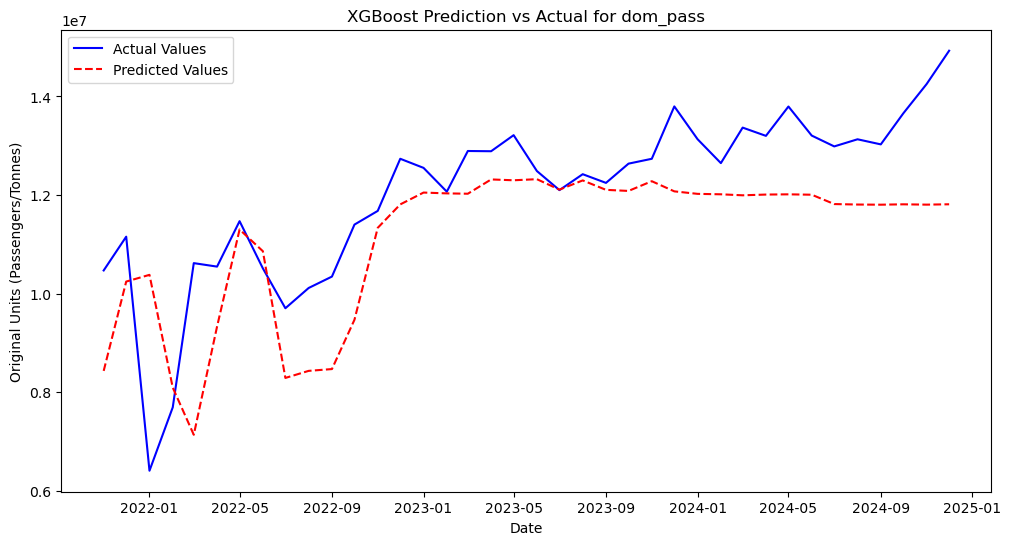


--- Performance Summary (XGBoost) ---
                  RMSE           MAE       MAPE
dom_pass  1.509777e+06  1.188410e+06  10.561064


In [13]:
import matplotlib.pyplot as plt

results = {}
print("\n--- Evaluating Model Performance ---")

print(f"\n--- Results for: {'dom_pass'} ---")
    
    # 1. Get the specific model and scaler
model = models['dom_pass']
scaler_y = scalers_y['dom_pass'] # Get the correct 'y' scaler
    
    # 2. Make predictions (on the scaled X_test data)
y_pred_scaled = model.predict(X_test_scaled)
    
    # 3. Get the true scaled values
y_test_scaled_true = y_test_scaled['dom_pass']
    
    # 4. Inverse Transform - Get back to original units
    # We use the original 'y_test' DataFrame for the true values
y_test_original = y_test['dom_pass']
    
    # Inverse transform the predictions
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    
    # 5. Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
epsilon = 1e-10 
mape = np.mean(np.abs((y_test_original - y_pred_original) / (y_test_original + epsilon))) * 100
    
print(f"RMSE: {rmse:.2f} (in original units)")
print(f"MAE:  {mae:.2f} (in original units)")
print(f"MAPE: {mape:.2f} %")
    
results['dom_pass'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

    # --- 6. Plot the results ---
plt.figure(figsize=(12, 6))
    # We must use the index from the y_test DataFrame to plot correctly
plt.plot(y_test_original.index, y_test_original, label='Actual Values', color='blue')
plt.plot(y_test_original.index, y_pred_original, label='Predicted Values', color='red', linestyle='--')
plt.title(f'XGBoost Prediction vs Actual for {'dom_pass'}')
plt.xlabel('Date')
plt.ylabel('Original Units (Passengers/Tonnes)')
plt.legend()
plt.show()

print("\n--- Performance Summary (XGBoost) ---")
results_df = pd.DataFrame(results).T
print(results_df)

In [14]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test_original, y_pred_original)
print(r2)

0.20634352134723266


# We have found that this model is best fitting on **dom_pass** with an accuracy of **89.49%** by using lags = 6 and added 3 - month rolling average. 

**Future Prediction**

In [14]:
future_date_str = '2025-01-01' # Example: The month *after* your last data point
future_exog_values = {
    'gdp': 3949765421913.18,            
    'population': 1486463625,    
    'jet_fuel': 179.04,
    'inflation': 4.62,
    'unemployment': 5.73,
    'exchange_rate': 84.8
}
print(f"\nForecasting for: {future_date_str}")


Forecasting for: 2025-01-01


In [15]:
def forecast_dom_pass(df_history, future_exog):
    """
    Forecasts the next step for domestic passengers using
    the 'simplified' feature set (6 lags, time, rolling).
    """
    print("--- Building 'dom_pass' feature vector ---")
    
    # Get the required column names from the scaler
    feature_names = scaler_X.get_feature_names_out()
    feature_dict = {}
    
    # 1. Add future exogenous values
    for col in future_exog:
        if col in feature_names:
            feature_dict[col] = future_exog[col]
            
    # 2. Add time features
    future_timestamp = pd.to_datetime(future_date_str)
    if 'month' in feature_names:
        feature_dict['month'] = future_timestamp.month
    if 'quarter' in feature_names:
        feature_dict['quarter'] = future_timestamp.quarter
    if 'year' in feature_names:
        feature_dict['year'] = future_timestamp.year
        
    # 3. Add lag features (n_lags = 6)
    n_lags = 6
    all_cols_to_lag = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight', 
                       'gdp', 'population', 'jet_fuel', 'inflation', 
                       'unemployment', 'exchange_rate']
                       
    for col in all_cols_to_lag:
        for i in range(1, n_lags + 1):
            feature_name = f'{col}_lag_{i}'
            if feature_name in feature_names:
                feature_dict[feature_name] = df_history[col].iloc[-i]

    # 4. Add rolling features (window = 3)
    target_cols = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight']
    for col in target_cols:
        feature_name = f'{col}_roll_avg_3'
        if feature_name in feature_names:
            feature_dict[feature_name] = df_history[col].iloc[-3:].mean()

    # 5. Convert to DataFrame and predict
    feature_row_df = pd.DataFrame([feature_dict], columns=feature_names)
    feature_row_scaled = scaler_X.transform(feature_row_df)
    prediction_scaled = model.predict(feature_row_scaled)
    prediction_original = scaler_y.inverse_transform(prediction_scaled.reshape(-1, 1))
    
    return prediction_original[0][0]

In [16]:
final_pass_forecast = forecast_dom_pass(df, future_exog_values)

--- Building 'dom_pass' feature vector ---


In [17]:
print("\n\n" + "="*30)
print("   🚀 FINAL FORECASTS 🚀")
print("="*30)
print(f"Forecast for Date: {future_date_str}")
print(f"Predicted Domestic Passengers: {final_pass_forecast:,.0f}")
print("="*30)



   🚀 FINAL FORECASTS 🚀
Forecast for Date: 2025-01-01
Predicted Domestic Passengers: 11,812,946


# Forecast

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

try:
    df_raw = pd.read_csv('preprocessed_historical_data.csv', index_col=0, parse_dates=True)
    df_future_exog = pd.read_csv('future_exog_data.csv', index_col=0, parse_dates=True)
    print("Successfully loaded historical and 15-step future data.")
except FileNotFoundError:
    print("Error: Could not find data files.")
    exit()

# Define Columns
target_cols = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight']
exog_cols = ['gdp', 'population', 'jet_fuel', 'inflation', 'unemployment', 'exchange_rate']

# --- 2. Feature Engineering Functions ---

def create_simplified_features(df):
    """
    PATH 1: For dom_pass (with outlier flag)
    This is the model that produces the flat line.
    """
    df_with_features = df.copy()
    
    # --- Outlier Detection ---
    rolling_mean = df_with_features['dom_pass'].shift(1).rolling(window=12).mean()
    rolling_std = df_with_features['dom_pass'].shift(1).rolling(window=12).std()
    threshold = rolling_mean - (3 * rolling_std)
    df_with_features['is_outlier'] = (df_with_features['dom_pass'] < threshold).astype(int)
    
    n_lags = 6
    cols_to_lag = target_cols + exog_cols + ['is_outlier']
    
    for col in cols_to_lag:
        if col in df_with_features.columns:
            for i in range(1, n_lags + 1):
                df_with_features[f'{col}_lag_{i}'] = df_with_features[col].shift(i)
            
    df_with_features['month'] = df_with_features.index.month
    df_with_features['quarter'] = df_with_features.index.quarter
    
    for col in target_cols:
        if col in df_with_features.columns:
            df_with_features[f'{col}_roll_avg_3'] = df_with_features[col].shift(1).rolling(window=3).mean()
        
    df_with_features = df_with_features.dropna()
    return df_with_features

def create_baseline_features(df):
    """PATH 2: For dom_freight (Baseline)"""
    n_lags = 12
    df_with_features = df.copy()
    for col in (target_cols + exog_cols):
        for i in range(1, n_lags + 1):
            df_with_features[f'{col}_lag_{i}'] = df_with_features[col].shift(i)
    df_with_features = df_with_features.dropna()
    return df_with_features

# --- 3. Recursive Forecasting Function ---

def forecast_ml_recursive(target_name, feature_gen_function, model, scaler_X, scaler_y, 
                          df_history, df_future_exog_full, n_steps):
    
    history_copy = df_history.copy()
    predictions = []
    
    # Slice the future data to the desired horizon
    df_future_exog_sliced = df_future_exog_full.iloc[:n_steps]

    for i in range(n_steps):
        future_date = df_future_exog_sliced.index[i]
        future_exog_row = df_future_exog_sliced.iloc[[i]].copy()

        temp_df = pd.concat([history_copy, future_exog_row])
        df_features_full = feature_gen_function(temp_df)
        
        feature_names = scaler_X.get_feature_names_out()
        
        X_to_predict_df = pd.DataFrame(columns=feature_names, index=[future_date])
        last_feature_row = df_features_full.iloc[[-1]]
        for col in feature_names:
            if col in last_feature_row.columns:
                X_to_predict_df[col] = last_feature_row[col].values
        X_to_predict_df = X_to_predict_df.fillna(0) 

        X_to_predict_scaled = scaler_X.transform(X_to_predict_df)
        y_pred_scaled = model.predict(X_to_predict_scaled)
        y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()[0]
        
        predictions.append(y_pred_original)
        
        # Update history
        history_copy.loc[future_date, target_name] = y_pred_original
        for col in df_future_exog_sliced.columns:
            if col in history_copy.columns:
                history_copy.loc[future_date, col] = future_exog_row[col].values[0]

    return pd.Series(predictions, index=df_future_exog_sliced.index)

# --- 4. Plot Forecast Function ---

def plot_forecast(df_history, forecast_series, target_name, model_name, n_steps):
    """Plots the historical data and the future forecast."""
    plt.figure(figsize=(14, 7))
    plt.plot(df_history.index[-50:], df_history[target_name].iloc[-50:], 
             label='Historical Actual', color='blue')
    plt.plot(forecast_series.index, forecast_series, 
             label='Future Forecast', color='red', linestyle='--')
    plt.title(f'{n_steps}-Step Forecast: {target_name} ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(f'forecast_plot_{target_name}_{n_steps}steps_direct.png')
    print(f"Saved forecast_plot_{target_name}_{n_steps}steps_direct.png")

# --- 5. Main Execution ---

# 5a. === Train 'dom_pass' Model ===
print("\n--- Training 'dom_pass' (Direct XGBoost) Model ---")
df_pass_features = create_simplified_features(df_raw)
X_full_pass = df_pass_features.drop(columns=[col for col in target_cols if col in df_pass_features.columns])
y_full_pass = df_pass_features['dom_pass']

scaler_X_pass_final = StandardScaler().fit(X_full_pass)
X_full_pass_scaled = scaler_X_pass_final.transform(X_full_pass)
scaler_y_pass_final = StandardScaler().fit(y_full_pass.to_frame())
y_full_pass_scaled = scaler_y_pass_final.transform(y_full_pass.to_frame())

final_pass_model = XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
final_pass_model.fit(X_full_pass_scaled, y_full_pass_scaled.ravel())
print("'dom_pass' model trained.")

# 5b. === Train 'dom_freight' Baseline Model ===
print("\n--- Training 'dom_freight' (Baseline) Model ---")
df_freight_features = create_baseline_features(df_raw)
X_full_freight = df_freight_features.drop(columns=[col for col in target_cols if col in df_freight_features.columns])
y_full_freight = df_freight_features['dom_freight']

scaler_X_freight_final = StandardScaler().fit(X_full_freight)
X_full_freight_scaled = scaler_X_freight_final.transform(X_full_freight)
scaler_y_freight_final = StandardScaler().fit(y_full_freight.to_frame())
y_full_freight_scaled = scaler_y_freight_final.transform(y_full_freight.to_frame())

best_freight_params = {
    'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7
}
final_freight_model = XGBRegressor(
    objective='reg:squarederror', n_jobs=-1, random_state=42, **best_freight_params
)
final_freight_model.fit(X_full_freight_scaled, y_full_freight_scaled.ravel())
print("'dom_freight' model trained.")

# 5c. === Generate Forecasts for 5, 10, 15 steps ===
forecast_horizons = [5, 10]
all_forecasts = {}

print("\n--- Generating Forecasts for all horizons ---")

for n in forecast_horizons:
    print(f"\n--- HORIZON: {n} STEPS ---")
    
    # --- 'dom_pass' (Direct Model) ---
    pass_forecast = forecast_ml_recursive(
        target_name='dom_pass',
        feature_gen_function=create_simplified_features,
        model=final_pass_model,
        scaler_X=scaler_X_pass_final,
        scaler_y=scaler_y_pass_final,
        df_history=df_raw,
        df_future_exog_full=df_future_exog,
        n_steps=n
    )
    all_forecasts[f'dom_pass_{n}'] = pass_forecast
    
    # --- 'dom_freight' (Baseline) ---
    freight_forecast = forecast_ml_recursive(
        target_name='dom_freight',
        feature_gen_function=create_baseline_features,
        model=final_freight_model,
        scaler_X=scaler_X_freight_final,
        scaler_y=scaler_y_freight_final,
        df_history=df_raw,
        df_future_exog_full=df_future_exog,
        n_steps=n
    )
    all_forecasts[f'dom_freight_{n}'] = freight_forecast

# --- 6. Display Final Forecasts and Plots ---
print("\n\n" + "="*40)
print("   🚀 FINAL FORECASTS 🚀")
print("="*40)

for n in forecast_horizons:
    print(f"\n--- {n}-Step Forecast for Domestic Passengers ---")
    print(all_forecasts[f'dom_pass_{n}'].to_frame(name='dom_pass_forecast').applymap('{:,.0f}'.format))
    
    print(f"\n--- {n}-Step Forecast for Domestic Freight ---")
    print(all_forecasts[f'dom_freight_{n}'].to_frame(name='dom_freight_forecast').applymap('{:,.0f}'.format))
    
    # Plot the forecasts
    plot_forecast(df_raw, all_forecasts[f'dom_pass_{n}'], 'dom_pass', 'XGBoost (Direct)', n)
    plot_forecast(df_raw, all_forecasts[f'dom_freight_{n}'], 'dom_freight', 'XGBoost (Tuned)', n)

print("\n✅ All forecasts and plots generated.")

Error: Could not find data files.

--- Training 'dom_pass' (Direct XGBoost) Model ---
'dom_pass' model trained.

--- Training 'dom_freight' (Baseline) Model ---
'dom_freight' model trained.

--- Generating Forecasts for all horizons ---

--- HORIZON: 5 STEPS ---


NameError: name 'df_future_exog' is not defined

: 